## importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Reading and Processing Data

In [3]:
df=pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
df.to_csv("insurance.csv",index=False)

In [7]:
df.to_csv("C:/Users/Dell/Downloads/insurance.csv", index=False)

### data quality check

In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## univariate analysis ( analysis of only one column)

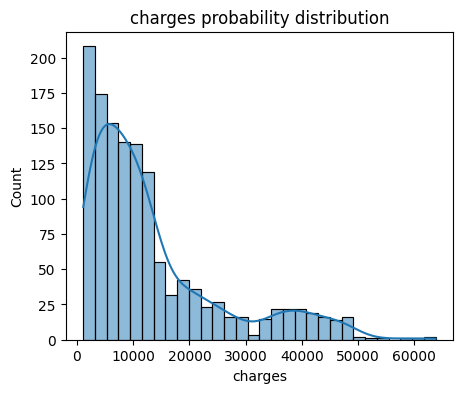

In [11]:
# df["charges"] is to be analysed
plt.figure(figsize=(5,4))
sns.histplot(x="charges",data=df,kde=True)
plt.title("charges probability distribution")
plt.show()

In [4]:
df["charges"].skew()

np.float64(1.5158796580240388)

In [ ]:
# right skewed (positively skewed)> +0.5
# -0.5 to +0.5 (standard)
# left skewed (negatively skewed) < -0.5
# kde=True is used to find distribution or skeweness 
# where the bell shape or from where 
# target variable/columns, in every data there is one column which is very crucial
# input variable/columns, all input variables are related to the target variable

In [14]:
df["charges"].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

## descreptive analysis ( by multivariate analysis or using more than columns)

In [ ]:
# descreptive analysis means studying the pattern of the data
# here we will study the relation on all the 6 "input variables/columns"
# and their relation with the "target variables"
# 3,2 for 6 graphs (so we took 3 rows 2 columns for 6 graphs)
# fig- large plot (fig,axes here "," comma is used 
#to denote for smaller inside the larger)
# axes- small plots (axes [0,0],[0,1] etc with respect to rows and column no of graph)
# 1st graph shows, "positive regression" means as "age" increase "charges" increase
# 2nd shows, "no impact" whether it is male or female 'charges' are same
# 3rd shows, "nigative regression" means "bmi" increased "charges" decreases
# 4th shows, children <2 : charges increase
#            children =2 : chagres stable or avg
#            children >2 : charges increase
# it is due to insurance company thinks that whosoever have no children means
# the cleint is completely dependent on the insurance company.
# 5th shows, "positie regression" if client is "smoker" charges increases
# 6th shows, "no impact"

Text(0.5, 1.0, '6 region vs Charges')

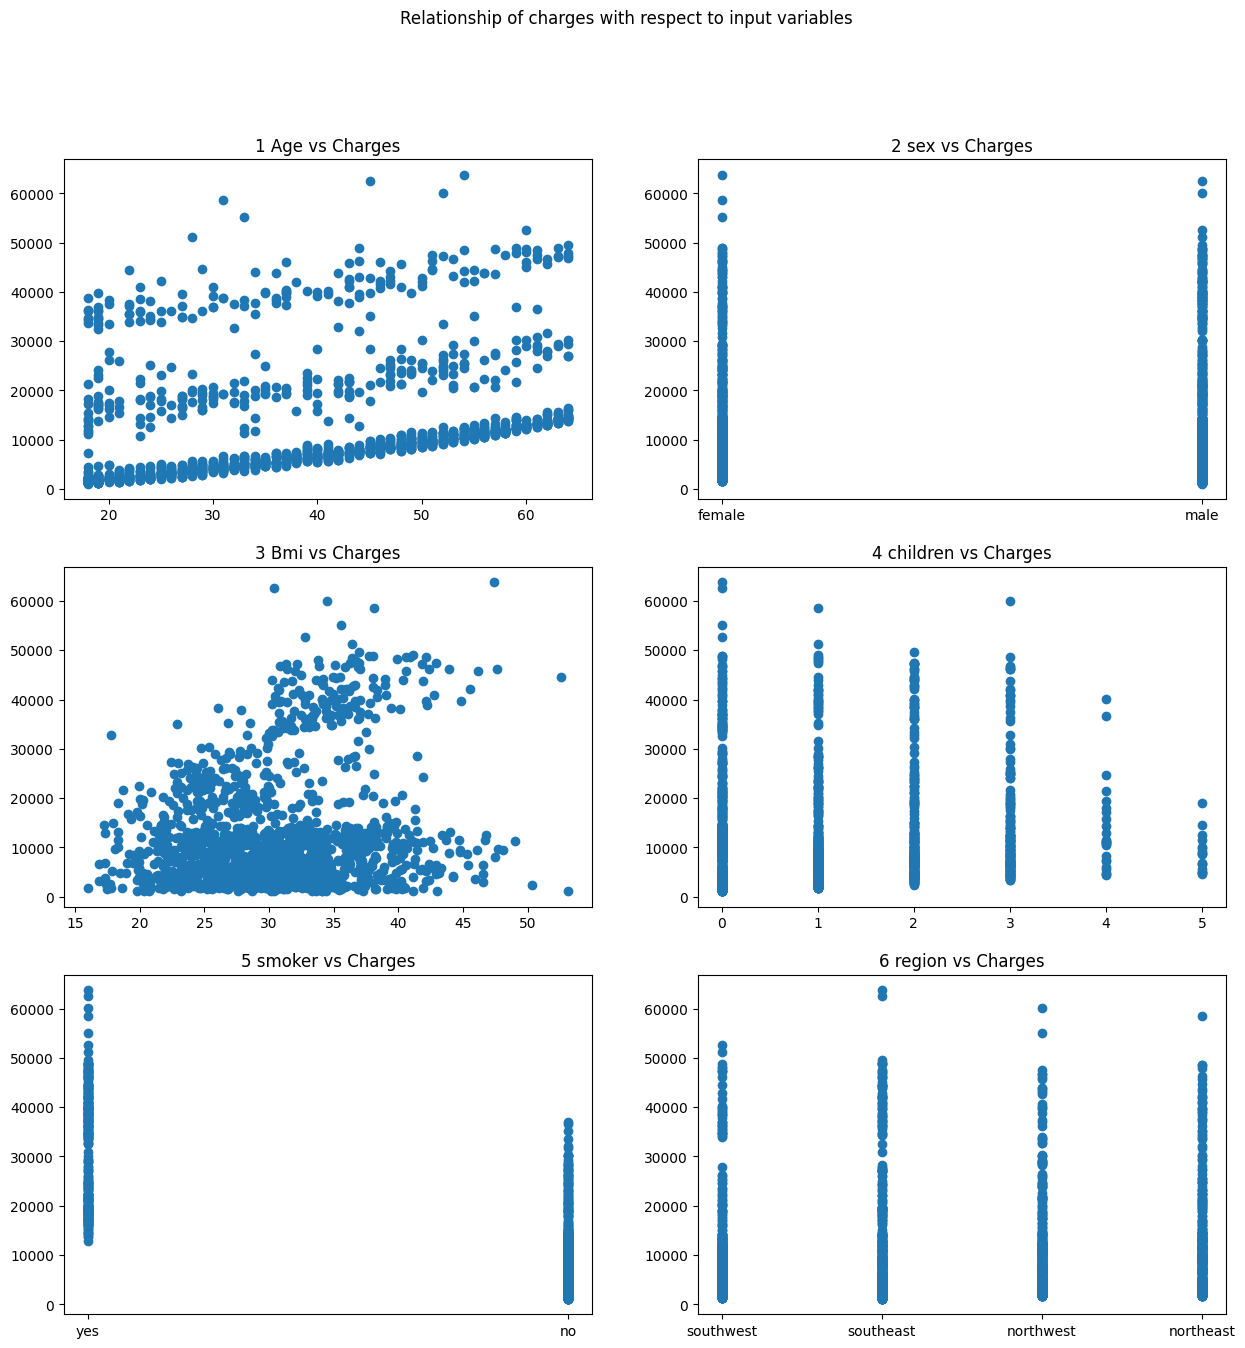

In [32]:
fig,axes=plt.subplots(3,2,figsize=(15,15))
fig.suptitle("Relationship of charges with respect to input variables")
axes[0,0].scatter(df["age"],df["charges"])
axes[0,0].set_title("1 Age vs Charges")
axes[0,1].scatter(df["sex"],df["charges"])
axes[0,1].set_title("2 sex vs Charges")
axes[1,0].scatter(df["bmi"],df["charges"])
axes[1,0].set_title("3 Bmi vs Charges")
axes[1,1].scatter(df["children"],df["charges"])
axes[1,1].set_title("4 children vs Charges")
axes[2,0].scatter(df["smoker"],df["charges"])
axes[2,0].set_title("5 smoker vs Charges")
axes[2,1].scatter(df["region"],df["charges"])
axes[2,1].set_title("6 region vs Charges")


## statistics analysis ( a part of descreptive analysis)

In [ ]:
# to find avg of smokers and non smokers

In [7]:
print("average charges of smoker",":",df[df["smoker"]=="yes"]["charges"].mean())
print("average charges of non smoker",":",df[df["smoker"]=="no"]["charges"].mean())

average charges of smoker : 32050.23183153284
average charges of non smoker : 8434.268297856204


In [8]:
print("average charges of smoker",":",df[df["smoker"]=="yes"]["charges"].mean().round())
print("average charges of non smoker",":",df[df["smoker"]=="no"]["charges"].mean().round())

average charges of smoker : 32050.0
average charges of non smoker : 8434.0


In [ ]:
# now we will create new df from this avg to visualise it

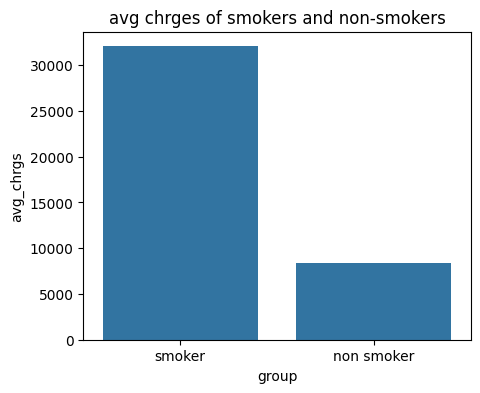

In [4]:
avg_df=pd.DataFrame({
    "group":["smoker","non smoker"],
    "avg_chrgs":[32050.0,8434.0]
})
plt.figure(figsize=(5,4))
sns.barplot(x="group", y="avg_chrgs",data=avg_df)
plt.title("avg chrges of smokers and non-smokers")
plt.show()

In [ ]:
# analysis on age we will create age group/binning by looping it
# we used "," - will not be acceptable

In [9]:
for age_range in [(0,25),(26,40),(41,50),(51,100)]:
    lower_bound,upper_bound=age_range
    print("average charges of age-range",age_range,":")

average charges of age-range (0, 25) :
average charges of age-range (26, 40) :
average charges of age-range (41, 50) :
average charges of age-range (51, 100) :


In [ ]:
# now we will create connection with df

In [12]:
for age_range in [(0,25),(26,40),(41,50),(51,100)]:
    lower_bound,upper_bound=age_range
    print("average charges of age-range",age_range,":",df[(df["age"]>=lower_bound)&
   (df["age"]<=upper_bound)]["charges"].mean().round())

average charges of age-range (0, 25) : 9087.0
average charges of age-range (26, 40) : 11097.0
average charges of age-range (41, 50) : 14782.0
average charges of age-range (51, 100) : 18085.0


In [ ]:
# , vs - comma is mandatory for python functions - is used here only justo to show range in graph

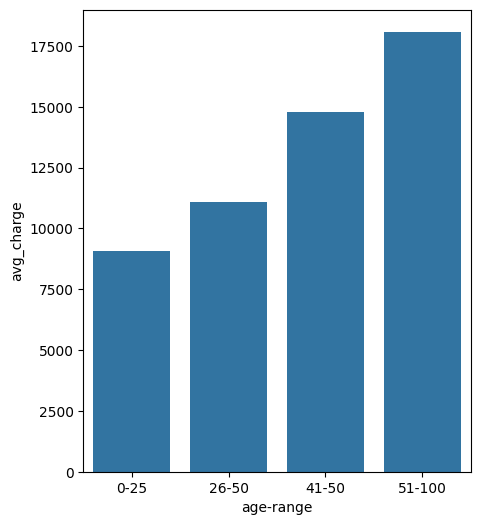

In [22]:
avg_age_df=pd.DataFrame({
    "age-range":["0-25","26-50","41-50","51-100"],
    "avg_charge":[9087.0,11097.0,14782.0,18085.0]
        })
plt.figure(figsize=(5,6))
sns.barplot(x="age-range",y="avg_charge",data=avg_age_df)
plt.show()

In [ ]:
# for bmi
#lower_bound,upper_bound=bmi_range used here as a sense of df.shape
# df.shape gives ie.(1338,7)
#rwos,column=df.shape, now you print row it will give 1338, and column 7

In [10]:
for bmi_range in [(0,18),(19,24),(25,29),(30,35),(36,100)]:
    lower_bound,upper_bound=bmi_range
    print("agerage charges of bmi range",bmi_range,":",df[(df["bmi"]>lower_bound)&(df["bmi"]<upper_bound)]
    ["charges"].mean().round())

agerage charges of bmi range (0, 18) : 7576.0
agerage charges of bmi range (19, 24) : 9741.0
agerage charges of bmi range (25, 29) : 11090.0
agerage charges of bmi range (30, 35) : 14429.0
agerage charges of bmi range (36, 100) : 16981.0


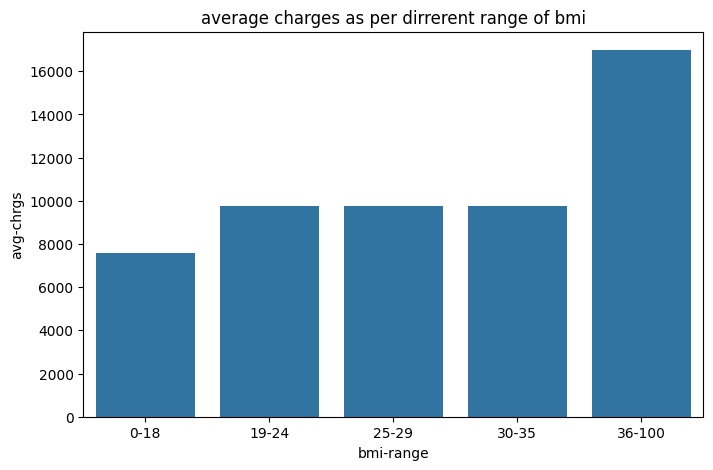

In [12]:
avg_df=pd.DataFrame({
    "bmi-range":["0-18","19-24","25-29","30-35","36-100"],
    "avg-chrgs":[7576.0,9741.0,9741.0,9741.0,16981.0]
})
plt.figure(figsize=(8,5))
sns.barplot(x="bmi-range",y="avg-chrgs",data=avg_df)
plt.title("average charges as per dirrerent range of bmi")
plt.show()

In [ ]:
# now we will study region

In [13]:
df["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [14]:
for region in df["region"].unique():
    print(region)

southwest
southeast
northwest
northeast


In [15]:
for region in df["region"].unique():
    print("average_charges as per region",region,":")

average_charges as per region southwest :
average_charges as per region southeast :
average_charges as per region northwest :
average_charges as per region northeast :


In [17]:
for region in df["region"].unique():
    print("average_charges as per region",region,":",df[df["region"]==region]["charges"].mean().round())

average_charges as per region southwest : 12347.0
average_charges as per region southeast : 14735.0
average_charges as per region northwest : 12418.0
average_charges as per region northeast : 13406.0


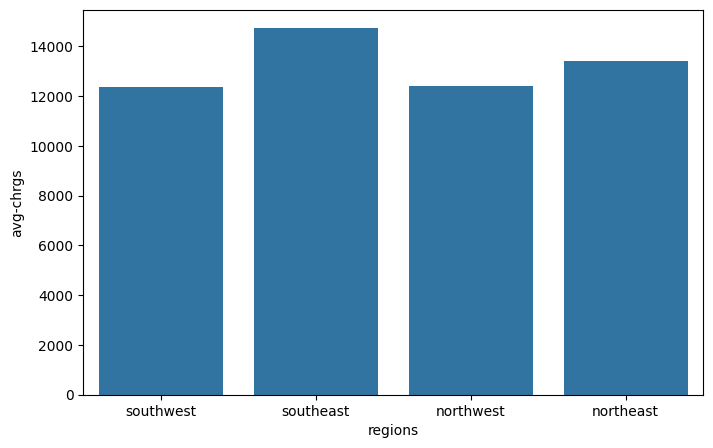

In [21]:
avg_df=pd.DataFrame({
    "regions":["southwest","southeast","northwest","northeast"],
    "avg-chrgs":[12347.0,14735.0,12418.0,13406.0]
})
plt.figure(figsize=(8,5))
sns.barplot(x="regions",y="avg-chrgs",data=avg_df)
plt.show()

In [ ]:
# analysis of children column

In [24]:
df.children.unique()

array([0, 1, 3, 2, 5, 4])

In [11]:
for children in ([0, 1, 3, 2, 5, 4]):
    print(children)
# or 
for children in df.children.unique():
    print("agerage charges for having",children,"child",df[df["children"]==children]["charges"].mean().round())

0
1
3
2
5
4
agerage charges for having 0 child 12366.0
agerage charges for having 1 child 12731.0
agerage charges for having 3 child 15355.0
agerage charges for having 2 child 15074.0
agerage charges for having 5 child 8786.0
agerage charges for having 4 child 13851.0


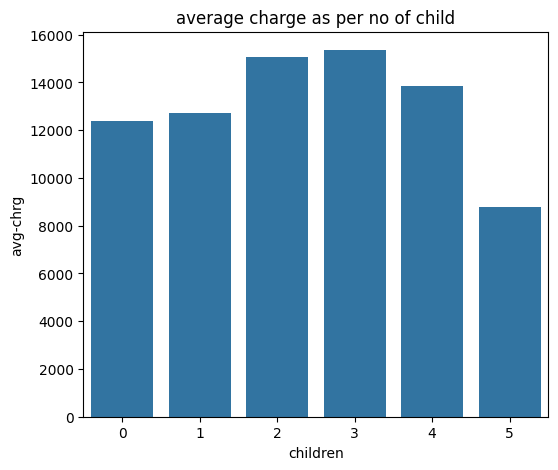

In [28]:
avg_chrg_chld=pd.DataFrame({
    "children":[0, 1, 3, 2, 5, 4],
    "avg-chrg":[12366.0,12731.0,15355.0,15074.0,8786.0,13851.0]
        })

plt.figure(figsize=(6,5))
sns.barplot(x="children",y="avg-chrg",data=avg_chrg_chld)
plt.title("average charge as per no of child")
plt.show()


In [ ]:
# analyse sex column

In [3]:
df.sex.unique()

array(['female', 'male'], dtype=object)

In [18]:
for sex in df.sex.unique():
    print("average charges for sex",sex,":")
    print("average charges for sex",sex,":",df[df["sex"]==sex]["charges"].mean().round())
     

    


average charges for sex female :
average charges for sex female : 12570.0
average charges for sex male :
average charges for sex male : 13957.0


      sex  avg_charges
0  female      12570.0
1    male      13957.0


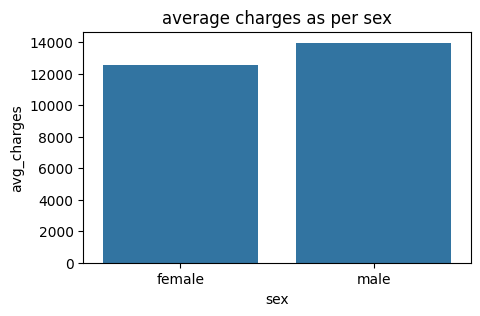

In [29]:
avg_sex_charges=pd.DataFrame({
    "sex":["female","male"],
    "avg_charges":[12570.0,13957.0]
})
print(avg_sex_charges)
plt.figure(figsize=(5,3))
sns.barplot(x="sex",y="avg_charges",data=avg_sex_charges)
plt.title("average charges as per sex")
plt.show()
